<a href="https://colab.research.google.com/github/Felipe2456/Aula-db/blob/main/cap11_12" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TABELA FINAL PARA O ARTIGO (MÉDIAS)
                   Tempo_ms  Payload_KB
Arquitetura                            
Síncrono (Base)      176.65      263.74
Assíncrono (AJAX)     64.24        1.67


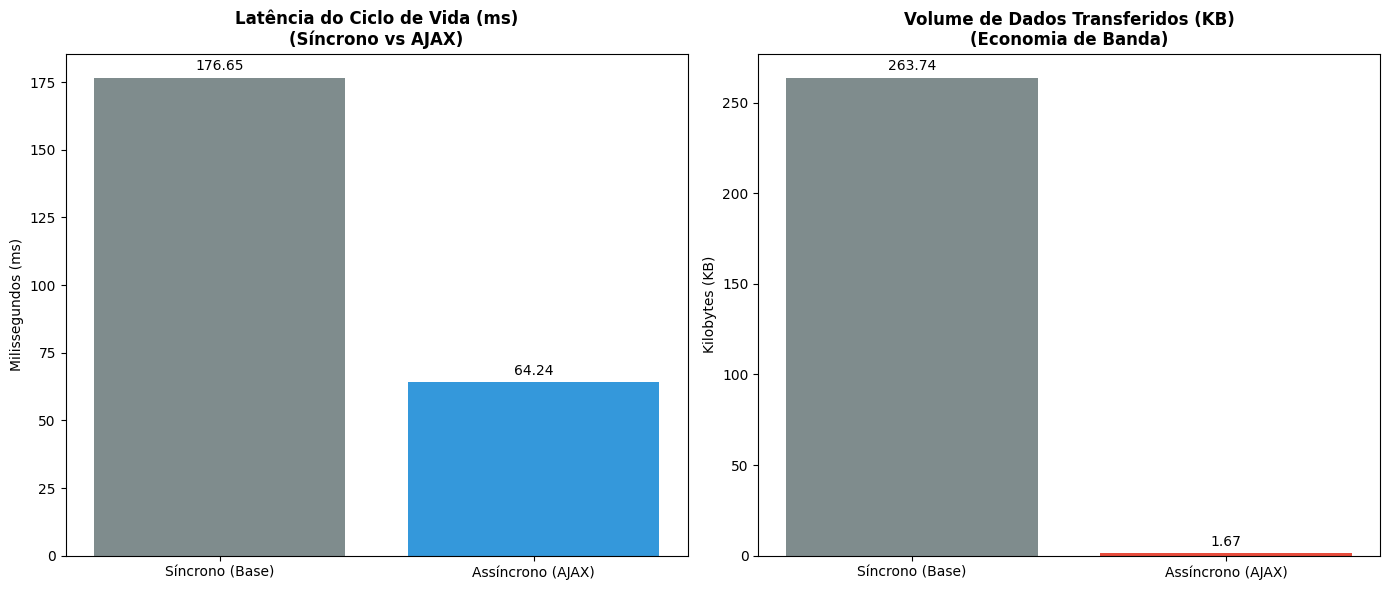


VALIDAÇÃO: O modelo assíncrono gerou uma economia de banda de 99.37%.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def aplicar_interceptador_seguranca():
    """Simula o custo computacional de um interceptador [12.7]."""
    return np.random.uniform(3, 10)

def simular_requisicao(tipo='sincrono'):
    """Simula fluxos baseados nos conceitos de Spring MVC e AJAX [11.19, 17.19]."""
    tempo_logica = np.random.normal(50, 10)
    overhead_seguranca = aplicar_interceptador_seguranca()

    if tipo == 'sincrono':
        payload = np.random.uniform(180, 350)  # Página HTML completa [17.18]
        tempo_renderizacao = 120               # Recarregamento total da UI
    else:
        payload = np.random.uniform(0.8, 2.5)  # Apenas JSON/Fragmento [11.19]
        tempo_renderizacao = 8                 # Atualização pontual do DOM

    tempo_total = tempo_logica + overhead_seguranca + tempo_renderizacao

    return {
        'Arquitetura': 'Síncrono (Base)',
        'Tempo_ms': round(tempo_total, 2),
        'Payload_KB': round(payload, 2)
    } if tipo == 'sincrono' else {
        'Arquitetura': 'Assíncrono (AJAX)',
        'Tempo_ms': round(tempo_total, 2),
        'Payload_KB': round(payload, 2)
    }

def executar_experimento(n=1000):
    dados = []
    for _ in range(n):
        dados.append(simular_requisicao('sincrono'))
        dados.append(simular_requisicao('assincrono'))
    return pd.DataFrame(dados)

# Gerar e processar dados
df = executar_experimento()
# Definindo a ordem explicitamente para o gráfico não sair "embaralhado"
df['Arquitetura'] = pd.Categorical(df['Arquitetura'], categories=['Síncrono (Base)', 'Assíncrono (AJAX)'], ordered=True)
tabela = df.groupby('Arquitetura', observed=False).mean().round(2)

print("TABELA FINAL PARA O ARTIGO (MÉDIAS)")
print(tabela)

# --- Visualização Otimizada ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Latência
bars1 = ax1.bar(tabela.index, tabela['Tempo_ms'], color=['#7f8c8d', '#3498db'])
ax1.set_title('Latência do Ciclo de Vida (ms)\n(Síncrono vs AJAX)', fontweight='bold')
ax1.set_ylabel('Milissegundos (ms)')
ax1.bar_label(bars1, padding=3)

# Gráfico 2: Tráfego de Rede (Payload)
bars2 = ax2.bar(tabela.index, tabela['Payload_KB'], color=['#7f8c8d', '#e74c3c'])
ax2.set_title('Volume de Dados Transferidos (KB)\n(Economia de Banda)', fontweight='bold')
ax2.set_ylabel('Kilobytes (KB)')
ax2.bar_label(bars2, padding=3)

plt.tight_layout()
plt.savefig('grafico.png', dpi=300) # Alta resolução para publicação
plt.show()

economia = ((1 - (tabela.loc['Assíncrono (AJAX)', 'Payload_KB'] / tabela.loc['Síncrono (Base)', 'Payload_KB'])) * 100)
print(f"\nVALIDAÇÃO: O modelo assíncrono gerou uma economia de banda de {economia:.2f}%.")